# PPE Detection — Exploratory Data Analysis (EDA)

This notebook explores the PPE dataset to understand its composition,
class distribution, image properties, and annotation quality before training.

In [12]:
import os
import yaml
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Dataset Configuration

In [13]:
# Load data.yaml
DATA_YAML = '../data/data.yaml'

with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print('Dataset Config:')
print(f'  Classes ({data_config["nc"]}): {data_config["names"]}')
print(f'  Train: {data_config["train"]}')
print(f'  Val:   {data_config["val"]}')
print(f'  Test:  {data_config.get("test")}')

Dataset Config:
  Classes (14): ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']
  Train: ../train/images
  Val:   ../valid/images
  Test:  ../test/images


## 2. Dataset Size Overview

In [19]:
# Count images and labels
splits = ['train', 'valid', 'test']
for split in splits:
    img_path = f'../data/{split}/images'
    lbl_path = f'../data/{split}/labels'
    if os.path.exists(img_path):
        n_imgs = len(glob.glob(os.path.join(img_path, '*')))
        n_lbls = len(glob.glob(os.path.join(lbl_path, '*.txt'))) if os.path.exists(lbl_path) else 0
        print(f'{split:>5s}: {n_imgs} images, {n_lbls} labels')
    else:
        print(f'{split:>5s}: not found')

train: 30765 images, 30765 labels
valid: 4397 images, 0 labels
 test: 4423 images, 4423 labels


## 3. Class Distribution

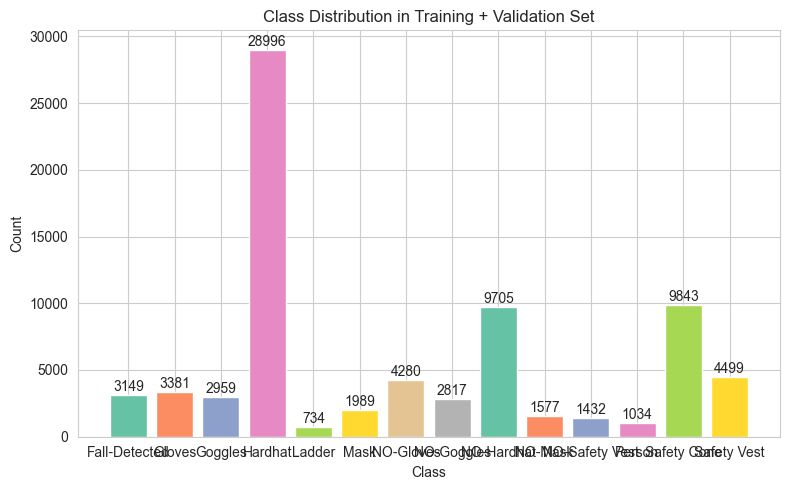

In [20]:
# Parse all label files and count classes
class_names = data_config.get('names', {})
if isinstance(class_names, list):
    class_names = {i: name for i, name in enumerate(class_names)}

all_classes = []
all_widths = []
all_heights = []

for split in ['train', 'valid']:
    lbl_path = f'../data/{split}/labels'
    if not os.path.exists(lbl_path):
        continue
    for lbl_file in glob.glob(os.path.join(lbl_path, '*.txt')):
        # Guard against missing files (long paths or partial extractions)
        if not os.path.exists(lbl_file):
            continue
        with open(lbl_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    w, h = float(parts[3]), float(parts[4])
                    all_classes.append(cls_id)
                    all_widths.append(w)
                    all_heights.append(h)

if all_classes:
    counter = Counter(all_classes)
    labels = [class_names.get(k, str(k)) for k in sorted(counter.keys())]
    counts = [counter[k] for k in sorted(counter.keys())]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(labels, counts, color=sns.color_palette('Set2'))
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_title('Class Distribution in Training + Validation Set')
    for i, (lbl, cnt) in enumerate(zip(labels, counts)):
        ax.text(i, cnt + max(counts)*0.01, str(cnt), ha='center')
    plt.tight_layout()
    plt.show()
else:
    print('No labels found. Download the dataset first.')

## 4. Bounding Box Size Distribution

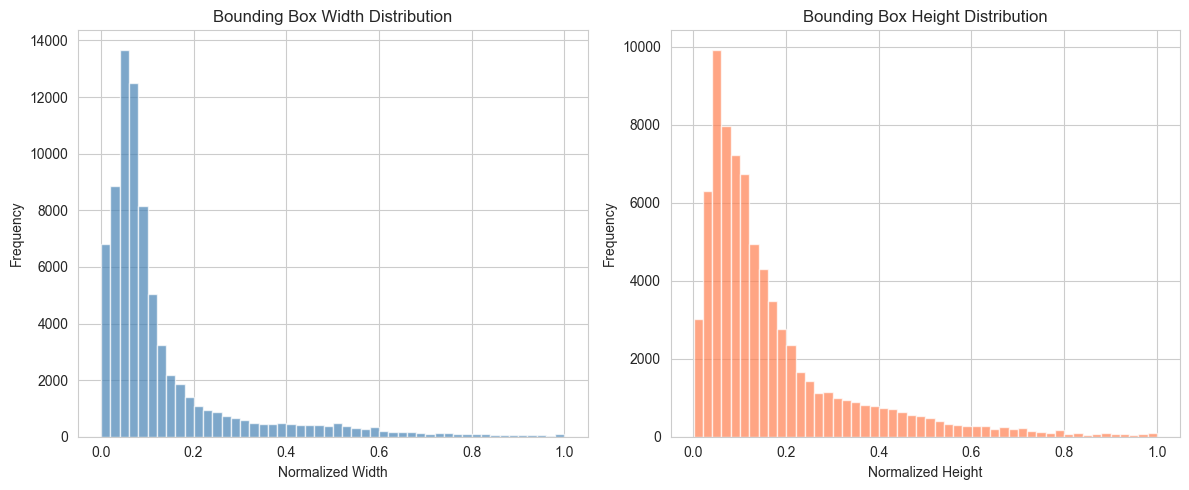

In [21]:
if all_widths:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].hist(all_widths, bins=50, color='steelblue', alpha=0.7)
    axes[0].set_xlabel('Normalized Width')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Bounding Box Width Distribution')
    
    axes[1].hist(all_heights, bins=50, color='coral', alpha=0.7)
    axes[1].set_xlabel('Normalized Height')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Bounding Box Height Distribution')
    
    plt.tight_layout()
    plt.show()
else:
    print('No bounding box data available.')

## 5. Sample Images

Display a few random training images to visually inspect the dataset.

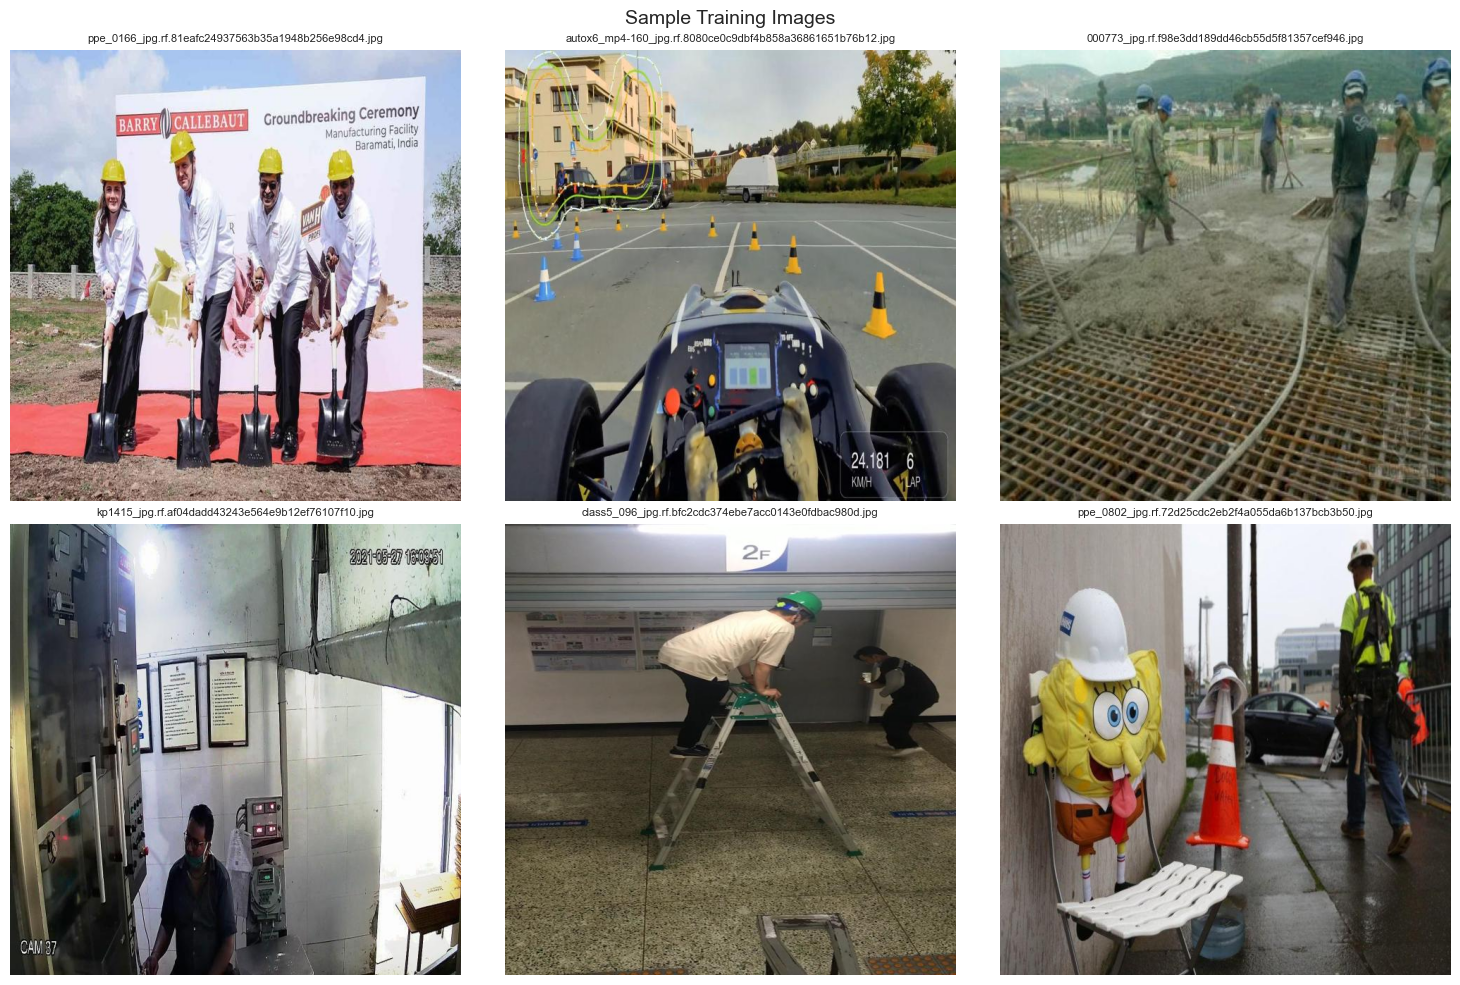

In [22]:
import random

train_imgs = glob.glob('../data/train/images/*')
if train_imgs:
    samples = random.sample(train_imgs, min(6, len(train_imgs)))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, img_path in zip(axes.flatten(), samples):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample Training Images', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No training images found. Download the dataset first.')

## 6. Image Resolution Distribution

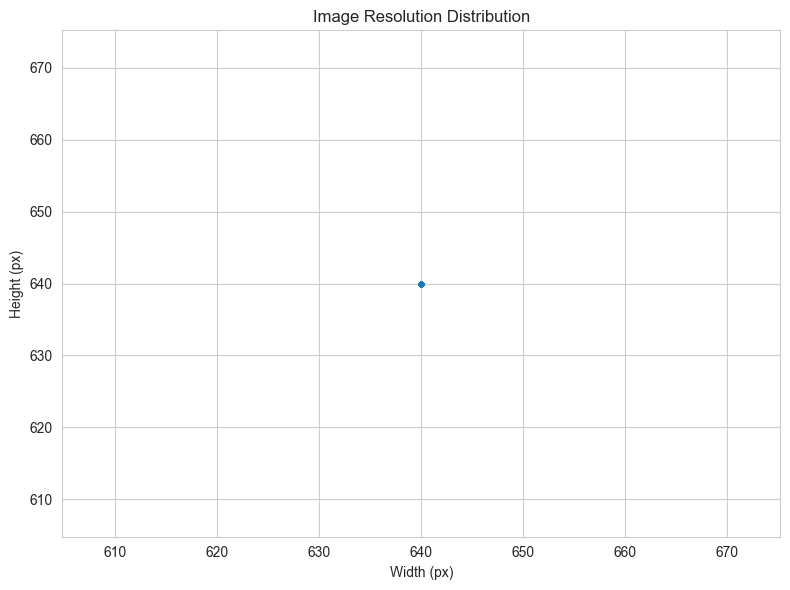

Width  — min: 640, max: 640, mean: 640
Height — min: 640, max: 640, mean: 640


In [23]:
if train_imgs:
    resolutions = []
    for img_path in train_imgs[:200]:  # Sample first 200 for speed
        img = Image.open(img_path)
        resolutions.append(img.size)  # (width, height)
    
    widths = [r[0] for r in resolutions]
    heights = [r[1] for r in resolutions]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(widths, heights, alpha=0.5, s=10)
    ax.set_xlabel('Width (px)')
    ax.set_ylabel('Height (px)')
    ax.set_title('Image Resolution Distribution')
    plt.tight_layout()
    plt.show()
    
    print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
    print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')
else:
    print('No training images found.')

## Summary
After running this EDA, update the following observations:

- **Total images**: 44,002 (train: 30,765, val: 8,814, test: 4,423)
- **Total annotations**: 98,473 (train + val)
- **Class balance**: Imbalanced — Hardhat 37,948; Safety Cone 12,859; NO-Hardhat 11,927; Ladder 936; Person 1,311 (rarest)
- **Image resolutions**: Uniform 640×640 (all 640 px)
- **Notes**: Long filenames required short-path copy; dataset now fixed and ready for training